<a href="https://colab.research.google.com/github/fanwenlin/TDDC17-lab/blob/lab3%2Ffwl/lab3/lab%203c%20-%20CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

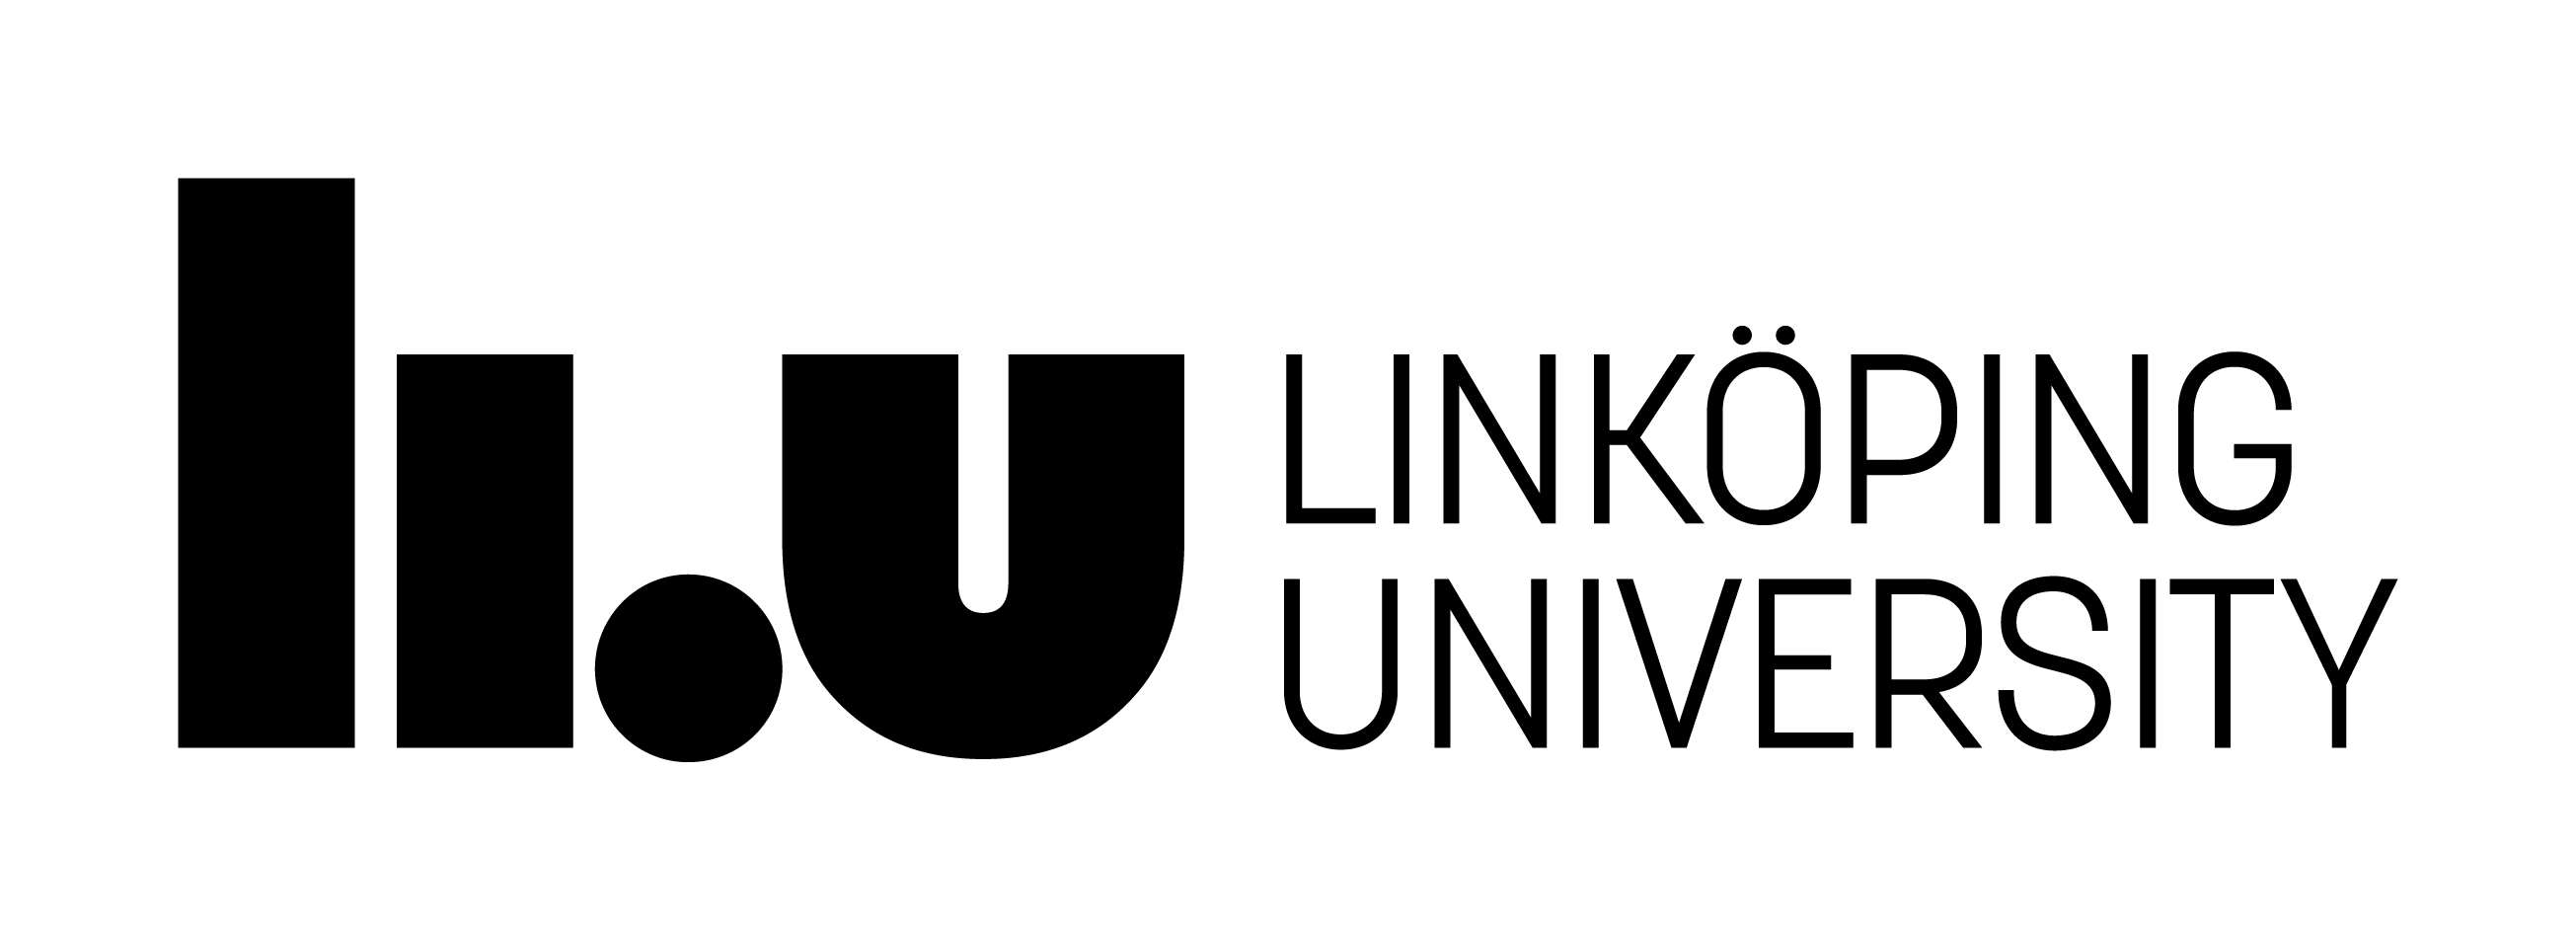
## Linkoping University: TDDC17 Artificial Intelligence
---



**Lab5 : Deep Learning**

**Lab5.3 :Convnet Implementation**

  In this assignment, you will learn how to implement a Convnet. We will use the deep learning library PyTorch, which is well-known for its ease of use

## Instaling and Loading packages

In [4]:
# !pip3 install torch torchvision==0.15.1+cu117  --exty'yra-index-url https://download.pytorch.org/whl/cu117
!pip3 install torch torchvision
!pip3 install numpy==1.26.0

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# function to count number of parameters
def get_n_params(model):
    np=0
    for p in list(model.parameters()):
        np += p.nelement()
    return np


#I. Load the Dataset (MNIST)

We can use some PyTorch DataLoader utilities for this. This will download, shuffle, normalize data and arrange it in batches.


In [6]:
input_size  = 28*28   # images are 28x28 pixels
output_size = 10      # there are 10 classes

train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=True, download=True,
                   transform=transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.1307,), (0.3081,))
                   ])),
    batch_size=64, shuffle=True)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=False, transform=transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.1307,), (0.3081,))
                   ])),
    batch_size=1000, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 636kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.65MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.5MB/s]


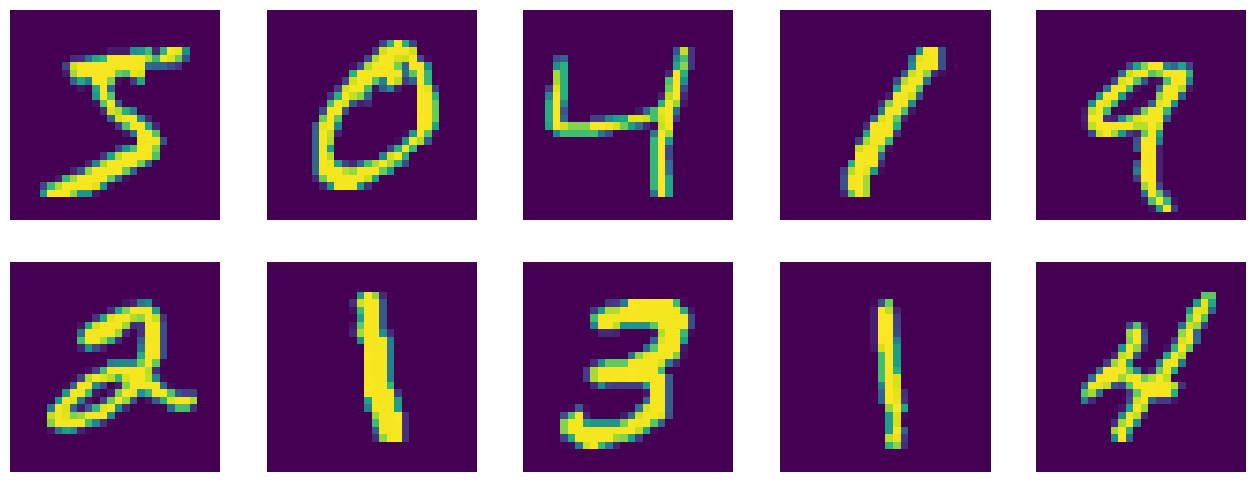

In [7]:
# show some images
plt.figure(figsize=(16, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    image, _ = train_loader.dataset[i]
    plt.imshow(image.squeeze().numpy())
    plt.axis('off');

#II. Create the model classes

In [12]:
class FC2Layer(nn.Module):
    def __init__(self, input_size, n_hidden, output_size):
        super(FC2Layer, self).__init__()
        self.input_size = input_size
        # Todo : Implement a fully connected neural network with two hidden layers using PyTorch's nn.Module.
        self.network = nn.Sequential(
            nn.Linear(input_size, n_hidden),
            nn.ReLU(),
            #< YOUR CODE HERE> add a hidden layer
            nn.Linear(n_hidden, n_hidden),
            #< YOUR CODE HERE> add a Relu activation function
            nn.ReLU(),
            #< YOUR CODE HERE> add the last layer
            nn.Linear(n_hidden, output_size),
            nn.LogSoftmax(dim=1)
        )

    def forward(self, x):
        x = x.view(-1, self.input_size)
        return self.network(x)

class CNN(nn.Module):
    def __init__(self, input_size, n_feature, output_size):
        super(CNN, self).__init__()
        # Todo : Implement 2 convolutional layers using nn.Conv2d(in_channels=1, out_channels, kernel_size=5).
        self.n_feature = n_feature
        self.input_size = input_size

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=n_features, kernel_size=5) #< YOUR CODE HERE>
        self.conv2 = nn.Conv2d(in_channels=n_features, out_channels=n_features, kernel_size=5) #< YOUR CODE HERE>
        self.fc1 = nn.Linear(n_feature*4*4, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x, verbose=False):
        # Todo : Complete the forward pass  implementation
        x = self.conv1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2) #< YOUR CODE HERE>   add a max pooling layer using F.max_pool2d(x, kernel_size=2)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2) #< YOUR CODE HERE> add a max pooling layer using F.max_pool2d(x, kernel_size=2)
        x = x.view(-1, self.n_feature*4*4)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.log_softmax(x, dim=1)
        return x

In [9]:
accuracy_list = []

def train(epoch, model, perm=torch.arange(0, 784).long()):
    #< YOUR CODE HERE>  call model.train
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        # send to device
        data, target = data.to(device), target.to(device)

        # permute pixels
        data = data.view(-1, 28*28)
        data = data[:, perm]
        data = data.view(-1, 1, 28, 28)

        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target) #< YOUR CODE HERE>  call F.nll_loss to compute the loss
        loss.backward() #< YOUR CODE HERE>  backward pass
        optimizer.step()
        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))

def test(model, perm=torch.arange(0, 784).long()):
    #< YOUR CODE HERE>  call model.eval
    model.eval()
    test_loss = 0
    correct = 0
    for data, target in test_loader:
        # send to device
        data, target = data.to(device), target.to(device)

        # permute pixels
        data = data.view(-1, 28*28)
        data = data[:, perm]
        data = data.view(-1, 1, 28, 28)
        output = model(data)
        test_loss += F.nll_loss(output, target, reduction='sum').item() # sum up batch loss
        pred = output.data.max(1, keepdim=True)[1] # get the index of the max log-probability
        correct += pred.eq(target.data.view_as(pred)).cpu().sum().item()

    test_loss /= len(test_loader.dataset)
    accuracy = 100. * correct / len(test_loader.dataset)
    accuracy_list.append(accuracy)
    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        accuracy))

#III. Train a small fully-connected network

In [10]:
n_hidden = 8 # number of hidden units

model_fnn = FC2Layer(input_size, n_hidden, output_size)
model_fnn.to(device)
optimizer = optim.SGD(model_fnn.parameters(), lr=0.01, momentum=0.5)
print('Number of parameters: {}'.format(get_n_params(model_fnn)))

for epoch in range(0, 1):
    train(epoch, model_fnn)
    test(model_fnn)

Number of parameters: 6442
Train Epoch: 0 [0/60000 (0%)]	Loss: 2.357924
Train Epoch: 0 [6400/60000 (11%)]	Loss: 1.681856
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.993159
Train Epoch: 0 [19200/60000 (32%)]	Loss: 0.660588
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.441675
Train Epoch: 0 [32000/60000 (53%)]	Loss: 0.677532
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.346801
Train Epoch: 0 [44800/60000 (75%)]	Loss: 0.465475
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.343235
Train Epoch: 0 [57600/60000 (96%)]	Loss: 0.387310

Test set: Average loss: 0.3808, Accuracy: 8874/10000 (89%)



#IV. Train a ConvNet with the same number of parameters

In [13]:
# Training settings
n_features = 6 # number of feature maps

model_cnn = CNN(input_size, n_features, output_size)
model_cnn.to(device)
optimizer = optim.SGD(model_cnn.parameters(), lr=0.01, momentum=0.5)
print('Number of parameters: {}'.format(get_n_params(model_cnn)))

for epoch in range(0, 1):
    train(epoch, model_cnn)
    test(model_cnn)

Number of parameters: 6422
Train Epoch: 0 [0/60000 (0%)]	Loss: 2.300975
Train Epoch: 0 [6400/60000 (11%)]	Loss: 2.017455
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.485007
Train Epoch: 0 [19200/60000 (32%)]	Loss: 0.352967
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.274549
Train Epoch: 0 [32000/60000 (53%)]	Loss: 0.341055
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.198086
Train Epoch: 0 [44800/60000 (75%)]	Loss: 0.261328
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.310420
Train Epoch: 0 [57600/60000 (96%)]	Loss: 0.093018

Test set: Average loss: 0.1304, Accuracy: 9604/10000 (96%)



#Questions

*   Compare the results of Fully-connected network and the Convnet
*   Which one has better performance , why?



## Answers
ConvNet has accuracy of 94% on test set while FC network only has 89%.

ConvNet has better performance. Because Convolutional calculation is spatial-awared. Can extract spatial feature more efficently.

Sources:

- https://github.com/Atcold/pytorch-Deep-Learning
- Dive into Deep learning [link](https://www.d2l.ai/chapter_multilayer-perceptrons/index.html)
- https://cs231n.github.io/convolutional-networks/